**Introduccción**

En este proyecto analizaremos el comportamiento de los usuarios dentro de la aplicación de una empresa emergente de productos alimenticios. El objetivo es comprender cómo avanzan los usuarios a través del embudo de ventas y detectar en qué etapas se producen mayores pérdidas antes de la compra.

Además, evaluaremos los resultados de un experimento A/A/B diseñado para medir el impacto de un cambio en la tipografía de la aplicación. Compararemos los grupos de control (246 y 247) para validar la consistencia del experimento, y posteriormente analizaremos si el nuevo diseño (grupo 248) influye en la conversión.

El propósito final es generar recomendaciones basadas en datos para apoyar la toma de decisiones del equipo de producto y diseño.

In [51]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

# Ver primeras filas
df.head()

# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [52]:
df.columns = (
    df.columns
    .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)
    .str.lower()
)

In [53]:
df.columns

Index(['event_name', 'device_idhash', 'event_timestamp', 'exp_id'], dtype='object')

In [54]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   event_name       244126 non-null  object
 1   device_idhash    244126 non-null  int64 
 2   event_timestamp  244126 non-null  int64 
 3   exp_id           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


event_name         0
device_idhash      0
event_timestamp    0
exp_id             0
dtype: int64

In [55]:
df['event_datetime'] = pd.to_datetime(df['event_timestamp'], unit='s')

In [56]:
df['event_date'] = df['event_datetime'].dt.date

In [57]:
df[['event_timestamp', 'event_datetime', 'event_date']].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   device_idhash    244126 non-null  int64         
 2   event_timestamp  244126 non-null  int64         
 3   exp_id           244126 non-null  int64         
 4   event_datetime   244126 non-null  datetime64[ns]
 5   event_date       244126 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB


In [58]:
#Paso 3. Estudiar y comprobar los pasos.

df.shape[0]

244126

El dataset contiene 244,126 eventos registrados.
Cada evento representa una acción realizada por un usuario dentro de la aplicación.

In [59]:
#Cantidad de usuarios

df['device_idhash'].nunique()

7551

En el dataset se registran 7,551 usuarios únicos, quienes generaron un total de 244,126 eventos dentro de la aplicación.

In [60]:
#Promedio de eventos por usuario

total_events = df.shape[0]
total_users = df['device_idhash'].nunique()

avg_events_per_user = total_events / total_users
avg_events_per_user

32.33028737915508

Cada usuario generó en promedio 32.33 eventos en la aplicación.
Esto indica un nivel de interacción relativamente alto, lo que sugiere que los usuarios exploran múltiples funcionalidades antes de abandonar o realizar una compra.

In [61]:
#Fecha máxima y mínima

df['event_datetime'].min()


Timestamp('2019-07-25 04:43:36')

In [62]:
df['event_datetime'].max()

Timestamp('2019-08-07 21:15:17')

In [63]:
#Agrupación por día

events_per_day = (
    df.groupby('event_date')
      .size()
)

events_per_day

event_date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
dtype: int64

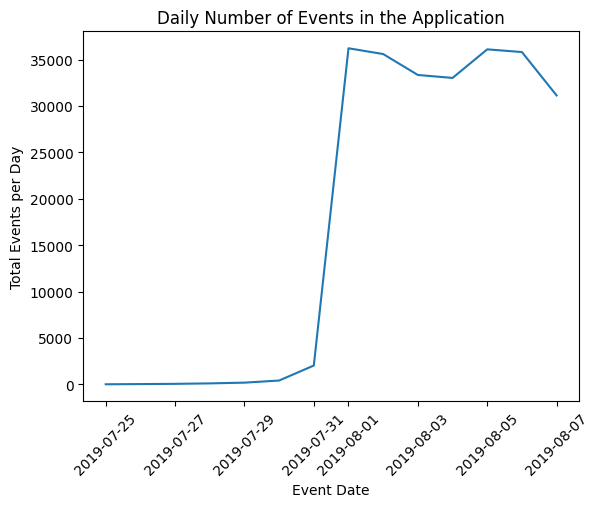

In [64]:
import matplotlib.pyplot as plt

plt.figure()
events_per_day.plot()
plt.title('Daily Number of Events in the Application')
plt.xlabel('Event Date')
plt.ylabel('Total Events per Day')
plt.xticks(rotation=45)
plt.show()

Aunque los datos originales comienzan el 25 de julio de 2019, el volumen de eventos es significativamente menor durante los primeros días, lo que sugiere registros incompletos.

A partir del 1 de agosto de 2019, el volumen se estabiliza en aproximadamente 33–36 mil eventos diarios.

Por lo tanto, el análisis se realizará utilizando únicamente los datos desde el 1 de agosto hasta el 7 de agosto de 2019.

In [65]:
df = df[df['event_datetime'] >= '2019-08-01']

In [66]:
df['event_datetime'].min()


Timestamp('2019-08-01 00:07:28')

In [67]:
df['event_datetime'].max()

Timestamp('2019-08-07 21:15:17')

In [68]:
# Eventos y usuarios ANTES del filtro

df_full = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
df_full.columns = (
    df_full.columns
    .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)
    .str.lower()
)

df_full['event_timestamp'] = pd.to_datetime(df_full['event_timestamp'], unit='s')

# Antes del filtro
events_before = df_full.shape[0]
users_before = df_full['device_idhash'].nunique()

# Aplicar filtro
df_filtered = df_full[df_full['event_timestamp'] >= '2019-08-01']

events_after = df_filtered.shape[0]
users_after = df_filtered['device_idhash'].nunique()

(
 (events_before - events_after)/events_before*100,
 (users_before - users_after)/users_before*100
)

(1.1584181938834865, 0.22513574361011784)

Al excluir los datos anteriores al 1 de agosto de 2019, se perdieron aproximadamente 1.16% de los eventos y 0.23% de los usuarios.

Dado que estos porcentajes son bajos, se concluye que la exclusión de los datos incompletos no afecta significativamente la representatividad del análisis.

In [69]:
#Usuarios por grupo

df.groupby('exp_id')['device_idhash'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: device_idhash, dtype: int64

Se confirmó la presencia de usuarios en los tres grupos experimentales (246, 247 y 248).

La distribución de usuarios es equilibrada entre los grupos, con aproximadamente un tercio del total asignado a cada uno. Por lo tanto, la asignación experimental se considera adecuada para proceder con el análisis A/A/B.

In [70]:
#Embudo de los eventos

event_counts = (
    df['event_name']
    .value_counts()
    .sort_values(ascending=False)
)

event_counts

MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: event_name, dtype: int64

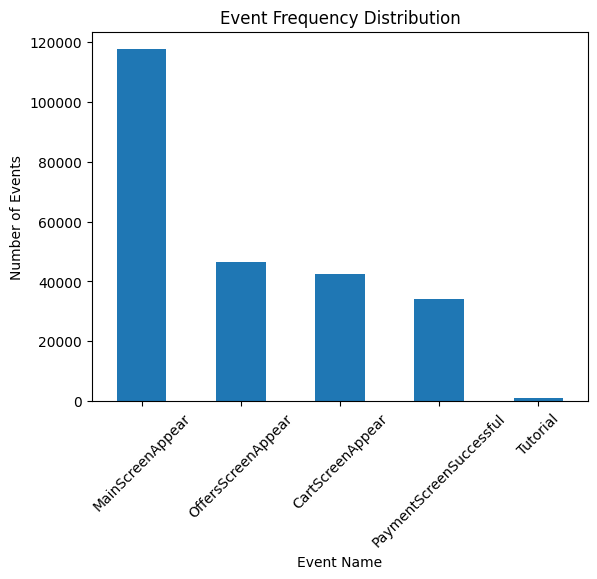

In [71]:
import matplotlib.pyplot as plt

event_counts = df['event_name'].value_counts()

plt.figure()
event_counts.plot(kind='bar')

plt.title('Event Frequency Distribution')
plt.xlabel('Event Name')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)

plt.show()

Se identificaron cinco eventos principales dentro de la aplicación.
El evento más frecuente fue MainScreenAppear, seguido por OffersScreenAppear, CartScreenAppear y PaymentScreenSuccessful.
La frecuencia decreciente sugiere un flujo consistente con un embudo de conversión típico.
El evento Tutorial presenta una frecuencia significativamente menor y no parece formar parte del flujo principal de compra.

In [72]:
#Usuarios únicos por evento

users_per_event = (
    df.groupby('event_name')['device_idhash']
      .nunique()
      .sort_values(ascending=False)
)

users_per_event

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: device_idhash, dtype: int64

In [73]:
#Proporción de usuarios
total_users = df['device_idhash'].nunique()

users_proportion = users_per_event / total_users
users_proportion

(users_per_event / total_users) * 100

event_name
MainScreenAppear           98.473586
OffersScreenAppear         60.963632
CartScreenAppear           49.561986
PaymentScreenSuccessful    46.973719
Tutorial                   11.149456
Name: device_idhash, dtype: float64

El análisis del embudo hasta ahora, muestra que el 98.47% de los usuarios accede a la pantalla principal, pero solo el 60.96% avanza a la sección de ofertas, representando la mayor pérdida de usuarios en el proceso.

La conversión entre etapas posteriores es considerablemente más alta, particularmente entre carrito y pago, donde la caída es mínima.

Por lo tanto, el principal cuello de botella se encuentra en la transición desde la pantalla principal hacia la visualización de ofertas.

In [74]:
#Proporción de usuarios que pasan por las etapas

funnel_users = (
    df[df['event_name'].isin([
        'MainScreenAppear',
        'OffersScreenAppear',
        'CartScreenAppear',
        'PaymentScreenSuccessful'
    ])]
    .groupby('event_name')['device_idhash']
    .nunique()
)

funnel_users

event_name
CartScreenAppear           3734
MainScreenAppear           7419
OffersScreenAppear         4593
PaymentScreenSuccessful    3539
Name: device_idhash, dtype: int64

In [75]:
funnel_users = funnel_users.reindex([
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
])

In [76]:
step_conversion = funnel_users.pct_change()
step_conversion

event_name
MainScreenAppear                NaN
OffersScreenAppear        -0.380914
CartScreenAppear          -0.187024
PaymentScreenSuccessful   -0.052223
Name: device_idhash, dtype: float64

In [77]:
conversion_main_to_offers = funnel_users['OffersScreenAppear'] / funnel_users['MainScreenAppear']

conversion_offers_to_cart = funnel_users['CartScreenAppear'] / funnel_users['OffersScreenAppear']

conversion_cart_to_payment = funnel_users['PaymentScreenSuccessful'] / funnel_users['CartScreenAppear']

conversion_main_to_offers, conversion_offers_to_cart, conversion_cart_to_payment

(0.6190861302062273, 0.8129762682342695, 0.9477771826459561)

El análisis del embudo muestra que la mayor pérdida de usuarios ocurre en la transición de la pantalla principal a la visualización de ofertas (61.9% de conversión).

Las etapas posteriores presentan tasas de conversión considerablemente más altas, especialmente entre carrito y pago (94.8%), lo que indica que el proceso de compra final es eficiente y presenta baja fricción.

Por lo tanto, el principal punto crítico del embudo se encuentra en la fase inicial de exploración de productos.

In [78]:
#Usuarios que recorren todo el embudo

total_users = df['device_idhash'].nunique()

users_completed_payment = df[df['event_name'] == 'PaymentScreenSuccessful']['device_idhash'].nunique()

overall_conversion = users_completed_payment / total_users

overall_conversion * 100

46.973719139899124

In [79]:
import matplotlib.pyplot as plt

total_users = df['device_idhash'].nunique()

funnel_percent = [
    funnel_users['MainScreenAppear'] / total_users * 100,
    funnel_users['OffersScreenAppear'] / total_users * 100,
    funnel_users['CartScreenAppear'] / total_users * 100,
    funnel_users['PaymentScreenSuccessful'] / total_users * 100
]

stages = [
    'Main Screen',
    'Offers',
    'Cart',
    'Payment'
]

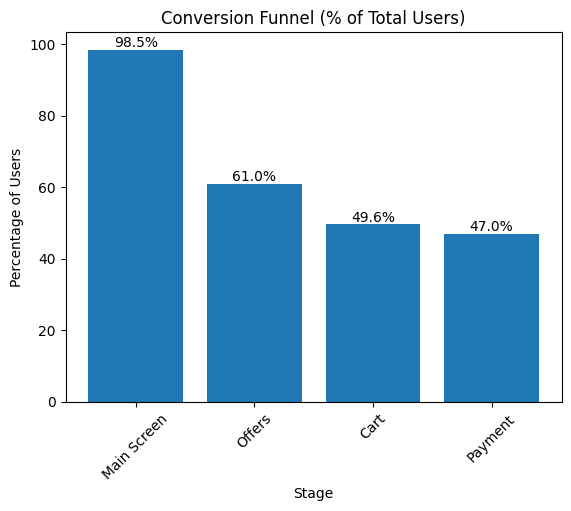

In [80]:
plt.figure()
bars = plt.bar(stages, funnel_percent)

plt.title('Conversion Funnel (% of Total Users)')
plt.xlabel('Stage')
plt.ylabel('Percentage of Users')

for i in range(len(funnel_percent)):
    plt.text(i, funnel_percent[i], f"{funnel_percent[i]:.1f}%", ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

Aproximadamente el 46.97% de los usuarios completan el recorrido hasta el pago exitoso.

Esta tasa de conversión global es elevada y sugiere que el proceso de compra es eficiente. El principal desafío del embudo se encuentra en la etapa inicial, donde una proporción significativa de usuarios no avanza hacia la visualización de ofertas.

In [81]:
#Paso 5. Estudiar los resultados del experimento

users_by_group = df.groupby('exp_id')['device_idhash'].nunique()

users_by_group

exp_id
246    2484
247    2513
248    2537
Name: device_idhash, dtype: int64

In [82]:
events_by_group = (
    df.groupby(['exp_id', 'event_name'])['device_idhash']
      .nunique()
      .unstack()
)

events_by_group

event_name,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial
exp_id,,,,,
246,1266,2450,1542,1200,278
247,1238,2476,1520,1158,283
248,1230,2493,1531,1181,279


In [83]:
#Prueba estadística

import math
from scipy import stats

def proportions_z_test(successes1, successes2, total1, total2):
    p1 = successes1 / total1
    p2 = successes2 / total2
    
    p_combined = (successes1 + successes2) / (total1 + total2)
    
    se = math.sqrt(p_combined * (1 - p_combined) * (1/total1 + 1/total2))
    
    z_score = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return z_score, p_value

In [84]:
z, p = proportions_z_test(
    events_by_group.loc[246, 'PaymentScreenSuccessful'],
    events_by_group.loc[247, 'PaymentScreenSuccessful'],
    users_by_group[246],
    users_by_group[247]
)

z, p

(1.5779948491596598, 0.11456679313141849)

Se realizó una prueba estadística de diferencia de proporciones entre los grupos de control 246 y 247.

El p-value obtenido fue 0.115, superior al nivel de significancia de 0.05.

Por lo tanto, no se encontraron diferencias estadísticamente significativas entre los grupos, lo que confirma la validez del diseño experimental y permite avanzar al análisis A/B.

In [85]:
#Evento mas popular: MainScreenAppear

def z_test_by_event(df, event_name):
    
    users_by_group = df.groupby('exp_id')['device_idhash'].nunique()
    
    event_users = (
        df[df['event_name'] == event_name]
        .groupby('exp_id')['device_idhash']
        .nunique()
    )
    
    successes1 = event_users[246]
    successes2 = event_users[247]
    
    total1 = users_by_group[246]
    total2 = users_by_group[247]
    
    p1 = successes1 / total1
    p2 = successes2 / total2
    
    p_combined = (successes1 + successes2) / (total1 + total2)
    
    se = math.sqrt(p_combined * (1 - p_combined) * (1/total1 + 1/total2))
    
    z_score = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return p1, p2, z_score, p_value

In [86]:
z_test_by_event(df, 'MainScreenAppear')

(0.9863123993558777,
 0.9852765618782332,
 0.3093441851418436,
 0.7570597232046099)

In [87]:
#Repetir para cada evento

events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

for event in events:
    result = z_test_by_event(df, event)
    print(event, result)

MainScreenAppear (0.9863123993558777, 0.9852765618782332, 0.3093441851418436, 0.7570597232046099)
OffersScreenAppear (0.6207729468599034, 0.6048547552725826, 1.154987713610383, 0.2480954578522181)
CartScreenAppear (0.5096618357487923, 0.4926382809391166, 1.203368576486285, 0.22883372237997213)
PaymentScreenSuccessful (0.4830917874396135, 0.46080382013529647, 1.5779948491596598, 0.11456679313141849)


Se realizaron pruebas de diferencia de proporciones entre los grupos de control 246 y 247 para cada etapa del embudo.

En todos los casos los p-values fueron mayores al nivel de significancia de 0.05, lo que indica que no existen diferencias estadísticamente significativas entre los grupos.

Esto confirma que la asignación experimental fue realizada correctamente y valida la confiabilidad del análisis A/B posterior.

In [88]:
#Comparación de grupos


def z_test_two_groups(df, event_name, group1, group2):
    
    users_by_group = df.groupby('exp_id')['device_idhash'].nunique()
    
    event_users = (
        df[df['event_name'] == event_name]
        .groupby('exp_id')['device_idhash']
        .nunique()
    )
    
    successes1 = event_users[group1]
    successes2 = event_users[group2]
    
    total1 = users_by_group[group1]
    total2 = users_by_group[group2]
    
    p1 = successes1 / total1
    p2 = successes2 / total2
    
    p_combined = (successes1 + successes2) / (total1 + total2)
    
    se = math.sqrt(p_combined * (1 - p_combined) * (1/total1 + 1/total2))
    
    z_score = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return p1, p2, z_score, p_value

In [89]:
#Comparación de 248 y 246

events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

for event in events:
    print(event, z_test_two_groups(df, event, 248, 246))

MainScreenAppear (0.9826566811194324, 0.9863123993558777, -1.0472762353383693, 0.2949721933554552)
OffersScreenAppear (0.6034686637761135, 0.6207729468599034, -1.2580821335711887, 0.20836205402738917)
CartScreenAppear (0.48482459597950334, 0.5096618357487923, -1.7598736474548398, 0.07842923237520116)
PaymentScreenSuccessful (0.46551044540796216, 0.4830917874396135, -1.2473878277158326, 0.2122553275697796)


In [90]:
#Comparación de 248 y 247

for event in events:
    print(event, z_test_two_groups(df, event, 248, 247))

MainScreenAppear (0.9826566811194324, 0.9852765618782332, -0.740980338642352, 0.4587053616621515)
OffersScreenAppear (0.6034686637761135, 0.6048547552725826, -0.1007086015299871, 0.9197817830592261)
CartScreenAppear (0.48482459597950334, 0.4926382809391166, -0.5554019078073092, 0.5786197879539783)
PaymentScreenSuccessful (0.46551044540796216, 0.46080382013529647, 0.3353759529753951, 0.7373415053803964)


In [91]:
df_combined = df.copy()
df_combined.loc[df_combined['exp_id'].isin([246,247]), 'exp_id'] = 246

In [92]:
for event in events:
    print(event, z_test_two_groups(df_combined, event, 248, 246))

MainScreenAppear (0.9826566811194324, 0.9857914748849309, -1.048854111361149, 0.29424526837179577)
OffersScreenAppear (0.6034686637761135, 0.6127676605963578, -0.7819303684733905, 0.43425549655188256)
CartScreenAppear (0.48482459597950334, 0.5011006603962378, -1.3353593793146474, 0.18175875284404386)
PaymentScreenSuccessful (0.46551044540796216, 0.47188312987792674, -0.5237830725856985, 0.6004294282308704)


Se compararon las proporciones de usuarios en cada etapa del embudo entre el grupo experimental (248) y los grupos de control combinados (246 y 247).

En ningún evento se encontraron diferencias estadísticamente significativas (p > 0.05).

Por lo tanto, el cambio de tipografía no tiene un impacto medible en el comportamiento de los usuarios ni en la conversión.

Se concluye que la implementación del nuevo diseño tipográfico no representa riesgo para las métricas clave del negocio.

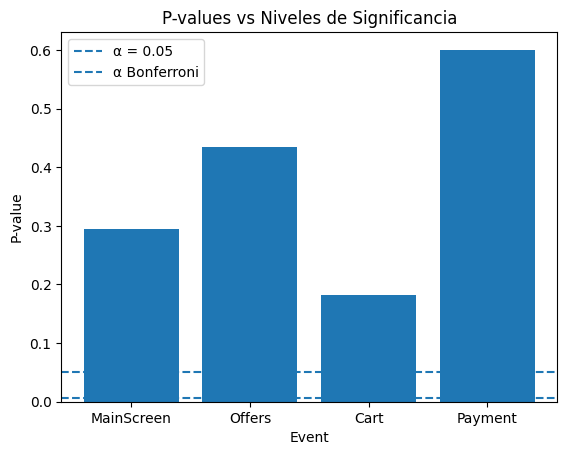

In [94]:
# P-values del A/B principal
events = [
    'MainScreen',
    'Offers',
    'Cart',
    'Payment'
]

p_values = [
    0.29424526837179577,
    0.43425549655188256,
    0.18175875284404386,
    0.6004294282308704
]

alpha = 0.05
adjusted_alpha = 0.05 / 8  # Bonferroni

plt.figure()
plt.bar(events, p_values)

plt.axhline(alpha, linestyle='--', label='α = 0.05')
plt.axhline(adjusted_alpha, linestyle='--', label='α Bonferroni')

plt.title('P-values vs Niveles de Significancia')
plt.ylabel('P-value')
plt.xlabel('Event')
plt.legend()

plt.show()

Se utilizó un nivel de significancia de α = 0.05 para las pruebas estadísticas.
En total se realizaron 8 pruebas de hipótesis.

Considerando el problema de múltiples comparaciones, se aplicó el razonamiento de la corrección de Bonferroni, obteniendo un α ajustado de aproximadamente 0.00625.

Dado que todos los p-values obtenidos fueron considerablemente superiores incluso a este umbral más estricto, las conclusiones del experimento se consideran estadísticamente robustas.

**Conclusión Final del Proyecto**

1. Análisis del embudo de conversión

El análisis del comportamiento de los usuarios mostró que:

El 98% accede a la pantalla principal.

Solo el 61.9% avanza a la sección de ofertas.

El 46.97% completa el pago exitosamente.

La mayor pérdida de usuarios ocurre en la transición de pantalla principal → ofertas, lo que indica que el principal cuello de botella del producto se encuentra en la etapa inicial de exploración.

Sin embargo, el proceso posterior —especialmente el checkout— presenta tasas de conversión muy altas (94.8% del carrito al pago), lo que sugiere una experiencia de compra eficiente y bien optimizada.

 2. Validación del experimento (A/A test)

Se compararon los dos grupos de control (246 y 247) en todas las etapas del embudo.

No se encontraron diferencias estadísticamente significativas (p > 0.05 en todos los eventos).

Esto confirma que la asignación aleatoria fue correcta.

Los grupos son comparables y el experimento es confiable.

3. Resultados del test A/B

Se comparó el grupo experimental (248, nuevas fuentes) contra los grupos de control combinados.

En ninguna etapa del embudo se encontraron diferencias estadísticamente significativas:

MainScreenAppear

OffersScreenAppear

CartScreenAppear

PaymentScreenSuccessful

Incluso aplicando corrección por múltiples comparaciones (Bonferroni), los resultados se mantienen consistentes.

En este orden de ideas, el cambio de tipografía:

- No reduce la conversión

- No genera fricción en el embudo

- No afecta el punto crítico (Main → Offers)

- No impacta el pago

Por lo tanto, el nuevo diseño tipográfico puede implementarse sin riesgo para las métricas clave del negocio.


Ahora bien, dado que el principal cuello de botella se encuentra en la transición hacia la visualización de ofertas, futuras optimizaciones deberían enfocarse en:

-Mejorar la claridad del llamado a la acción en la pantalla principal.

-Optimizar jerarquía visual y navegación inicial.

-Aumentar la tasa de exploración de productos.



Finalmente, no hay evidencia estadística que justifique rechazar la implementación del nuevo diseño.

Se recomienda proceder con el despliegue de las nuevas fuentes.